In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
print(df.info())
print("\nNulos por coluna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Nulos por coluna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_mar

Distribuição do target (stroke):
stroke
0    4861
1     249
Name: count, dtype: int64

Em percentual:
stroke
0    95.1
1     4.9
Name: proportion, dtype: float64


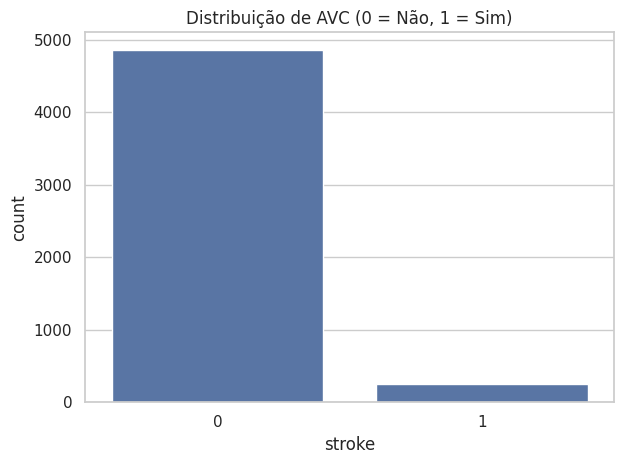

In [3]:
print("Distribuição do target (stroke):")
print(df["stroke"].value_counts())
print("\nEm percentual:")
print(df["stroke"].value_counts(normalize=True).round(3) * 100)

sns.countplot(data=df, x="stroke")
plt.title("Distribuição de AVC (0 = Não, 1 = Sim)")
plt.tight_layout()
plt.show()

In [4]:
# Verificar se existem linhas duplicadas no dataset
# Duplicatas podem distorcer o treinamento do modelo
print("Duplicatas:", df.duplicated().sum())

# Verificar os valores únicos das colunas categóricas
# Isso ajuda a identificar valores inesperados, erros de digitação
# ou categorias que precisam ser tratadas
print("\nValores únicos em gender:", df["gender"].unique())
print("Valores únicos em work_type:", df["work_type"].unique())
print("Valores únicos em smoking_status:", df["smoking_status"].unique())

Duplicatas: 0

Valores únicos em gender: ['Male' 'Female' 'Other']
Valores únicos em work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Valores únicos em smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


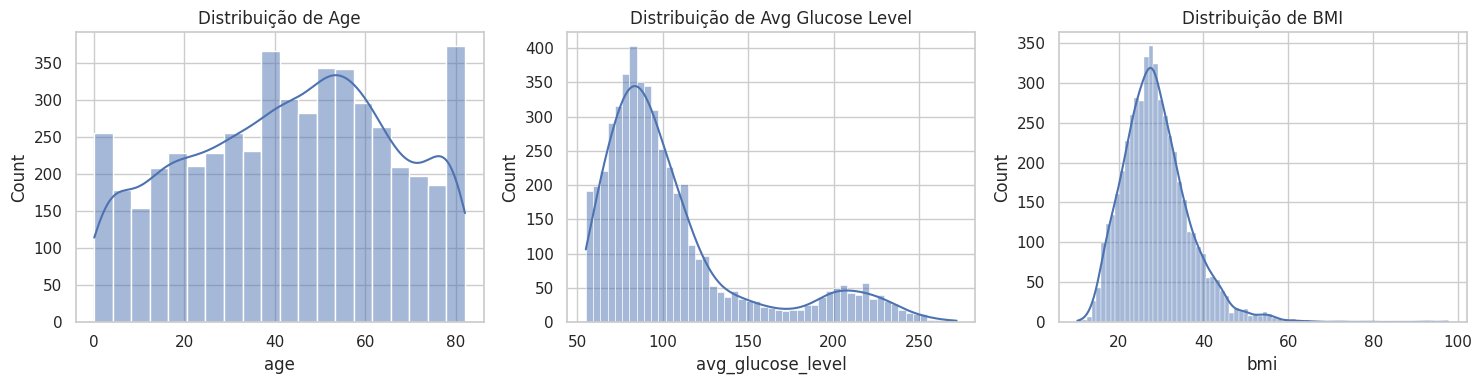

In [5]:
# Visualizar a distribuição das features numéricas
# Histogramas com curva de densidade (kde) ajudam a identificar
# caudas longas, bimodalidade e escala dos valores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribuição da idade
sns.histplot(df["age"], kde=True, ax=axes[0])
axes[0].set_title("Distribuição de Age")

# Distribuição da glicose média — valores altos podem indicar diabetes
sns.histplot(df["avg_glucose_level"], kde=True, ax=axes[1])
axes[1].set_title("Distribuição de Avg Glucose Level")

# Distribuição do IMC — valores ausentes já foram identificados
sns.histplot(df["bmi"].dropna(), kde=True, ax=axes[2])
axes[2].set_title("Distribuição de BMI")

plt.tight_layout()
plt.show()

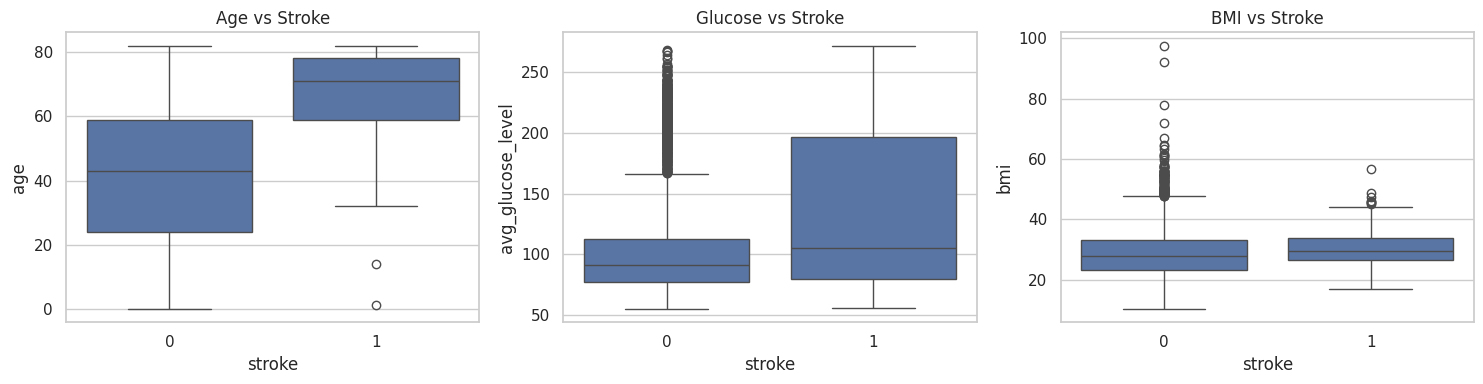

In [6]:
# Visualizar como cada feature se relaciona com o target stroke
# Boxplots mostram se a distribuição de uma feature numérica
# é diferente entre quem teve AVC (1) e quem não teve (0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x="stroke", y="age", ax=axes[0])
axes[0].set_title("Age vs Stroke")

sns.boxplot(data=df, x="stroke", y="avg_glucose_level", ax=axes[1])
axes[1].set_title("Glucose vs Stroke")

sns.boxplot(data=df, x="stroke", y="bmi", ax=axes[2])
axes[2].set_title("BMI vs Stroke")

plt.tight_layout()
plt.show()

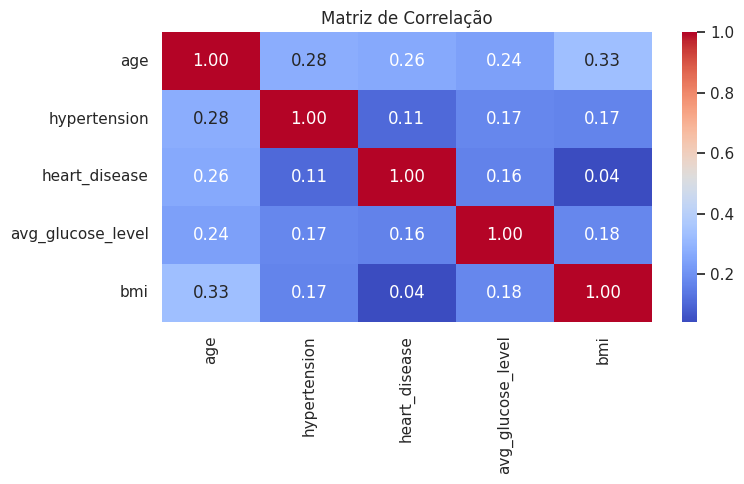

In [7]:
# Matriz de correlação apenas entre colunas numéricas
# Valores próximos de 1 ou -1 indicam forte relação entre features
# Correlações acima de 0.7 podem indicar multicolinearidade
numericas = df.select_dtypes(include="number").drop(columns=["id", "stroke"])

plt.figure(figsize=(8, 5))
sns.heatmap(numericas.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

In [8]:
# Remover coluna id — não tem valor preditivo, é só um identificador
df = df.drop(columns=["id"])

# Remover o único registro com gender = "Other"
# São apenas 1 caso, insuficiente para o modelo aprender
df = df[df["gender"] != "Other"]

# Preencher os 201 valores nulos de bmi com a mediana
# Mediana é mais robusta que média quando há outliers
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Verificar resultado final
print("Shape após limpeza:", df.shape)
print("Nulos restantes:")
print(df.isnull().sum())

Shape após limpeza: (5109, 11)
Nulos restantes:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [9]:
# Insights da EDA que vão guiar a modelagem
print("Insights da EDA:")
print("1. Dataset desbalanceado: 95.1% sem AVC e 4.9% com AVC — usar class_weight='balanced'")
print("2. Age é a feature mais importante: mediana de 70 anos em quem teve AVC vs 43 em quem não teve")
print("3. Avg_glucose_level elevado está associado ao AVC — bimodalidade identificada")
print("4. BMI tem 201 nulos — imputados com mediana")
print("5. Nenhuma correlação acima de 0.7 entre features — sem multicolinearidade")

# Salvar o dataset limpo para usar na modelagem
df.to_csv("../data/processed/stroke_limpo.csv", index=False)
print("\nDataset limpo salvo em data/processed/")

Insights da EDA:
1. Dataset desbalanceado: 95.1% sem AVC e 4.9% com AVC — usar class_weight='balanced'
2. Age é a feature mais importante: mediana de 70 anos em quem teve AVC vs 43 em quem não teve
3. Avg_glucose_level elevado está associado ao AVC — bimodalidade identificada
4. BMI tem 201 nulos — imputados com mediana
5. Nenhuma correlação acima de 0.7 entre features — sem multicolinearidade

Dataset limpo salvo em data/processed/
